In [ ]:
import kagglehub
import pandas as pd
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Download dataset
path = kagglehub.dataset_download("ziya07/diet-recommendations-dataset")

files = os.listdir(path)
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)


# Calculate BMI ourselves
df["BMI"] = df["Weight_kg"] / ((df["Height_cm"]/100) ** 2)


# Select required columns
df = df[[
    "Age",
    "Gender",
    "Weight_kg",
    "Height_cm",
    "BMI",
    "Disease_Type",
    "Severity",
    "Dietary_Nutrient_Imbalance_Score",
    "Diet_Recommendation"
]]


# Separate features and target
X = df.drop("Diet_Recommendation", axis=1)
y = df["Diet_Recommendation"]


# Encode categorical columns
label_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le


# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)


# Predictions
y_pred = model.predict(X_test)


# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Save model
joblib.dump(model, "diet_model.pkl")
joblib.dump(target_encoder, "diet_encoder.pkl")
joblib.dump(X.columns, "model_features.pkl")

print("Model saved successfully")

100%|██████████| 32.1k/32.1k [00:00<00:00, 37.2MB/s]

Extracting files...


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        86
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Model saved successfully


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Testing Accuracy:", accuracy)

Testing Accuracy: 1.0


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)

Recall: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        86
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[86  0  0]
 [ 0 47  0]
 [ 0  0 67]]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
pip install seaborn

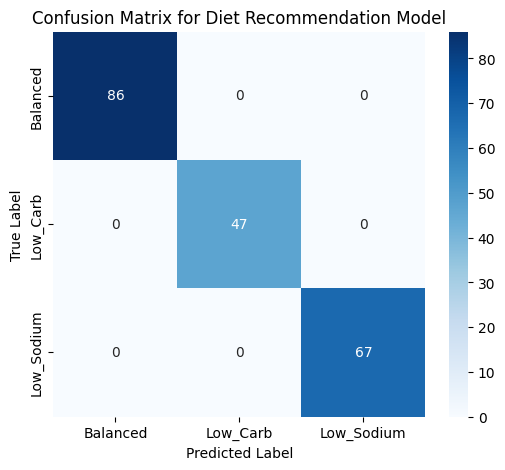

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Diet Recommendation Model")

plt.show()

In [ ]:
import pandas as pd

In [ ]:
model = joblib.load("/content/diet_model.pkl")
encoder = joblib.load("/content/diet_encoder.pkl")
features = joblib.load("/content/model_features.pkl")

In [ ]:
Age = 45
Gender = "Male"
Weight = 80
Height = 170
Disease_Type = "Diabetes"
Severity = "Moderate"
Dietary_Nutrient_Imbalance_Score = 60

In [ ]:
weight = 80
height_cm = 170

bmi = weight / ((height_cm/100)**2)

In [ ]:
gender = 1      # Male
disease = 1     # Diabetes
severity = 1    # Moderate

In [ ]:
sample = pd.DataFrame(
[[Age, gender, weight, height_cm, bmi, disease, severity, 60]],
columns=features
)

In [ ]:
prediction = model.predict(sample)

diet = encoder.inverse_transform(prediction)

print("Recommended Diet:", diet[0])

Recommended Diet: Low_Sodium


In [ ]:
import joblib
import pandas as pd

# load models
model = joblib.load("diet_model.pkl")
encoder = joblib.load("diet_encoder.pkl")
features = joblib.load("model_features.pkl")


# food category mapping
food_category_map = {

"apple_pie":"high_sugar",
"baby_back_ribs":"high_fat",
"baklava":"high_sugar",
"beef_carpaccio":"high_protein",
"beef_tartare":"high_protein",
"beet_salad":"healthy_food",
"beignets":"high_sugar",
"bibimbap":"mixed_meal",
"bread_pudding":"high_sugar",
"breakfast_burrito":"mixed_meal",
"bruschetta":"refined_carbs",
"caesar_salad":"healthy_food",
"cannoli":"high_sugar",
"caprese_salad":"healthy_food",
"carrot_cake":"high_sugar",
"ceviche":"high_protein",
"cheesecake":"high_sugar",
"cheese_plate":"high_fat",
"chicken_curry":"high_protein",
"chicken_quesadilla":"mixed_meal",
"chicken_wings":"fried_food",
"chocolate_cake":"high_sugar",
"chocolate_mousse":"high_sugar",
"churros":"high_sugar",
"clam_chowder":"high_sodium",
"club_sandwich":"refined_carbs",
"crab_cakes":"fried_food",
"creme_brulee":"high_sugar",
"croque_madame":"refined_carbs",
"cup_cakes":"high_sugar",
"deviled_eggs":"high_protein",
"donuts":"high_sugar",
"dumplings":"refined_carbs",
"edamame":"healthy_food",
"eggs_benedict":"high_protein",
"escargots":"high_protein",
"falafel":"fried_food",
"filet_mignon":"high_protein",
"fish_and_chips":"fried_food",
"foie_gras":"high_fat",
"french_fries":"fried_food",
"french_onion_soup":"high_sodium",
"french_toast":"refined_carbs",
"fried_calamari":"fried_food",
"fried_rice":"refined_carbs",
"frozen_yogurt":"high_sugar",
"garlic_bread":"refined_carbs",
"gnocchi":"refined_carbs",
"greek_salad":"healthy_food",
"grilled_cheese":"high_fat",
"grilled_salmon":"high_protein",
"guacamole":"healthy_food",
"gyoza":"fried_food",
"hamburger":"refined_carbs",
"hot_and_sour_soup":"high_sodium",
"hot_dog":"high_sodium",
"huevos_rancheros":"mixed_meal",
"hummus":"healthy_food",
"ice_cream":"high_sugar",
"lasagna":"refined_carbs",
"lobster_bisque":"high_fat",
"lobster_roll_sandwich":"refined_carbs",
"macaroni_and_cheese":"refined_carbs",
"macarons":"high_sugar",
"miso_soup":"high_sodium",
"mussels":"high_protein",
"nachos":"high_fat",
"omelette":"high_protein",
"onion_rings":"fried_food",
"oysters":"high_protein",
"pad_thai":"refined_carbs",
"paella":"mixed_meal",
"pancakes":"refined_carbs",
"panna_cotta":"high_sugar",
"peking_duck":"high_fat",
"pho":"mixed_meal",
"pizza":"refined_carbs",
"pork_chop":"high_protein",
"poutine":"high_fat",
"prime_rib":"high_fat",
"pulled_pork_sandwich":"refined_carbs",
"ramen":"refined_carbs",
"ravioli":"refined_carbs",
"red_velvet_cake":"high_sugar",
"risotto":"refined_carbs",
"samosa":"fried_food",
"sashimi":"high_protein",
"scallops":"high_protein",
"seaweed_salad":"healthy_food",
"shrimp_and_grits":"mixed_meal",
"spaghetti_bolognese":"refined_carbs",
"spaghetti_carbonara":"refined_carbs",
"spring_rolls":"fried_food",
"steak":"high_protein",
"strawberry_shortcake":"high_sugar",
"sushi":"mixed_meal",
"tacos":"mixed_meal",
"takoyaki":"fried_food",
"tiramisu":"high_sugar",
"tuna_tartare":"high_protein",
"waffles":"refined_carbs"
}

diet_rules= { "Low_Carb": { "avoid": [ "refined_carbs", "high_sugar" ],
                          "limit": [ "fried_food", "high_fat", "mixed_meal" ], "prefer": [ "high_protein", "healthy_food" ] }, "Low_Sodium": { "avoid": [ "high_sodium", "fried_food" ], "limit": [ "high_fat", "refined_carbs", "mixed_meal" ], "prefer": [ "healthy_food", "high_protein" ] }, "Balanced": { "avoid": [ "high_sugar" ], "limit": [ "fried_food", "high_fat" ], "prefer": [ "healthy_food", "high_protein", "mixed_meal", "refined_carbs" ] } }

def diet_food_recommendation(age, gender, weight, height,
                             disease, severity, imbalance_score,
                             detected_foods):

    # calculate BMI
    bmi = weight / ((height/100)**2)

    # encode categorical inputs
    gender_enc = 1 if gender.lower()=="male" else 0

    disease_map = {"none":0,"diabetes":1,"hypertension":2,"obesity":3}
    severity_map = {"mild":0,"moderate":1,"severe":2}

    disease_enc = disease_map.get(disease.lower(),0)
    severity_enc = severity_map.get(severity.lower(),0)

    # create dataframe for prediction
    sample = pd.DataFrame(
        [[age, gender_enc, weight, height, bmi,
          disease_enc, severity_enc, imbalance_score]],
        columns=features
    )

    # Random Forest predicts diet
    pred = model.predict(sample)
    diet = encoder.inverse_transform(pred)[0]

    # lists for results
    avoid_foods = []
    limit_foods = []
    safe_foods = []

    # check foods against predicted diet rules
    for food in detected_foods:

        category = food_category_map.get(food)

        if category is None:
            safe_foods.append(food)
            continue

        if category in diet_rules[diet]["avoid"]:
            avoid_foods.append(food)

        elif category in diet_rules[diet]["limit"]:
            limit_foods.append(food)

        else:
            safe_foods.append(food)

    # result dictionary
    result = {
        "Recommended_Diet": diet,
        "Detected_Foods": detected_foods,
        "Avoid_Foods": avoid_foods,
        "Limit_Foods": limit_foods,
        "Safe_Foods": safe_foods
    }

    return result

In [ ]:
detected_foods = ["pizza", "salad", "steak"]

result = diet_food_recommendation(
age=45,
gender="male",
weight=80,
height=170,
disease="diabetes",
severity="moderate",
imbalance_score=60,
detected_foods=detected_foods
)

print(result)

{'Recommended_Diet': 'Low_Sodium', 'Detected_Foods': ['pizza', 'salad', 'steak'], 'Avoid_Foods': [], 'Limit_Foods': ['pizza'], 'Safe_Foods': ['salad', 'steak']}
